In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st

from pathlib import Path
from typing import Dict, List, Tuple

from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV, GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import ElasticNetCV, Ridge
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.inspection import permutation_importance

from xgboost import XGBRegressor
import xgboost as xgb
from lightgbm import LGBMRegressor
import lightgbm as lgb
from catboost import CatBoostRegressor

import optuna
import joblib
import logging


In [9]:
df = pd.read_parquet('../data/views/vw_ATD_dashboard.parquet')

In [11]:
def feature_selection(df_view):
    df = df_view.copy()
    df['ATD_log'] = np.log1p(df['ATD'].fillna(0))
    if "restaurant_offered_timestamp_local" in df.columns:
        df["rest_offer_missing"] = df["restaurant_offered_timestamp_local"].isna().astype(int)

    for col in ["pickup_distance", "dropoff_distance"]:
        
        nan_flag = f"{col}_nan"
        df[nan_flag] = df[col].isna().astype(int)
        
        
        df[col] = df.groupby(["territory", "day_of_week", "hour"])[col].transform(lambda s: s.fillna(s.mean()))
        
        df[col].fillna(df[col].median(), inplace=True)

    df["sin_hour"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["cos_hour"] = np.cos(2 * np.pi * df["hour"] / 24)

    for col in ["pickup_distance", "dropoff_distance"]:
        df[f"{col}_log"] = np.log1p(df[col])

    df["pickup_dropoff_ratio"] = (
        df["pickup_distance_log"] / df["dropoff_distance_log"]
    ).replace([np.nan, np.inf, -np.inf], 1)

    df = pd.get_dummies(df, columns=["courier_flow"], prefix="courier", drop_first=True)
    df = pd.get_dummies(df, columns=["geo_archetype"], prefix="geo", drop_first=True)
    df = pd.get_dummies(df, columns=["merchant_surface"], prefix="surface", drop_first=True)
    df = pd.get_dummies(df, columns=["region"], prefix="region", drop_first=True)
    df = pd.get_dummies(df, columns=["territory"], prefix="territory", drop_first=True)

    df['pickup_dropoff_ratio_winsor_log'] = np.log1p(df['pickup_dropoff_ratio'].clip(lower=df['pickup_dropoff_ratio'].quantile(0.01),
                                                                                        upper=df['pickup_dropoff_ratio'].quantile(0.99)))

    drops = ['country_name', 'workflow_uuid', 'driver_uuid', 'delivery_trip_uuid',
        'restaurant_offered_timestamp_utc', 'order_final_state_timestamp_local',
        'eater_request_timestamp_local', 'pickup_distance', 'dropoff_distance',
        'ATD', 'restaurant_offered_timestamp_local', 'date', 'ATD_winsor',
            'dropoff_distance_nan',
        'pickup_dropoff_ratio',
        'pickup_dropoff_ratio_log', 'pickup_dropoff_ratio_winsor']

    df_prep = df.drop(columns=drops, inplace=False, errors='ignore')
    df_prep = pd.get_dummies(df_prep, columns=["hour_bin", "driver_experience"], drop_first=True)

    return df_prep

In [12]:
df_prep = feature_selection(df)

/var/folders/mk/_ghzwf3j0hvf_yvj29dkl4lh0000gn/T/ipykernel_55999/2842701227.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[col] = df.groupby(["territory", "day_of_week", "hour"])[col].transform(lambda s: s.fillna(s.mean()))
/var/folders/mk/_ghzwf3j0hvf_yvj29dkl4lh0000gn/T/ipykernel_55999/2842701227.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the

In [14]:
best_params = {'max_depth': 9, 'learning_rate': 0.053063667959215785, 'subsample': 0.9424827068160501, 'colsample_bytree': 0.8181958016055538, 'reg_alpha': 1.1919263859193818, 'reg_lambda': 2.9934022301042242, 'min_child_weight': 2}

Mean Absolute Error (MAE): 0.2835
Root Mean Squared Error (RMSE): 0.3940
R-squared (R²): 0.4078


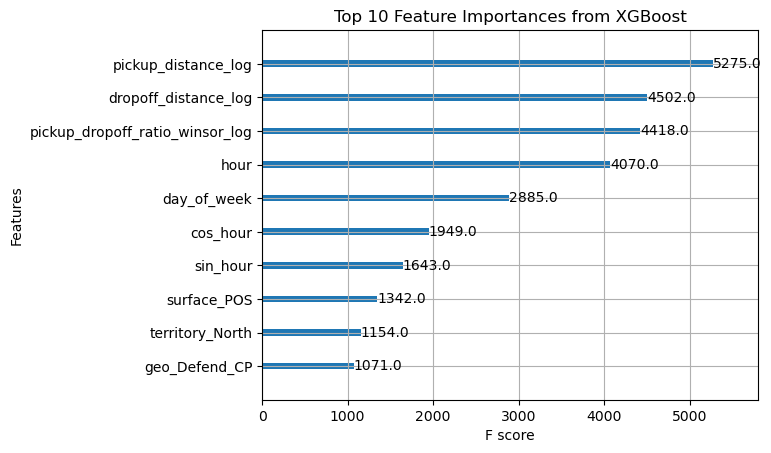

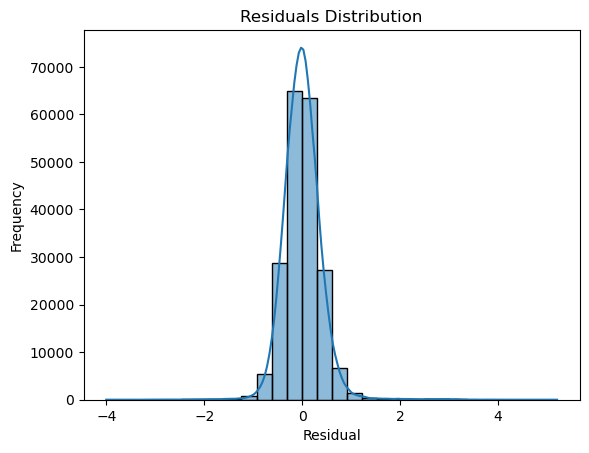

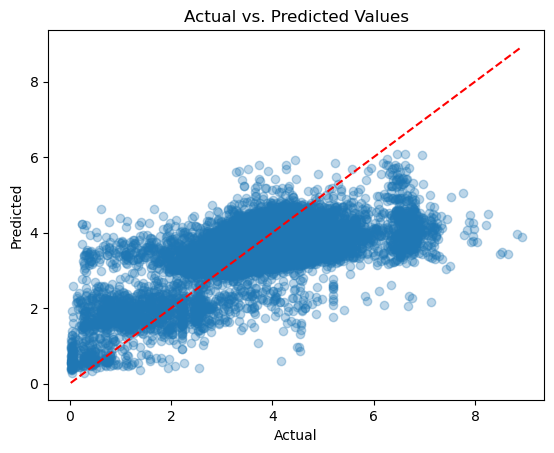

In [15]:
target = 'ATD_log'
X = df_prep.drop(columns=[target]).copy()
y = df_prep[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42)

cv = KFold(n_splits=5, shuffle=True, random_state=42)
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

model = XGBRegressor(**best_params)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R²): {r2:.4f}")

model.fit(X_train, y_train)
xgb.plot_importance(model, max_num_features=10)
plt.title('Top 10 Feature Importances from XGBoost')
plt.show()

residuals = y_test - y_pred
sns.histplot(residuals, bins=30, kde=True)
plt.title('Residuals Distribution')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.show()

plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs. Predicted Values')
plt.show()

In [18]:
joblib.dump(model, '../models/xgb_model.pkl')

['../models/xgb_model.pkl']

In [20]:
# Testeo del modelo con el loading
model = joblib.load('../models/xgb_model.pkl')

df_prep["ATD_log_pred"] = model.predict(X)
df_prep["ATD_pred"] = np.expm1(df_prep["ATD_log_pred"]) 
df_prep["ATD_true"] = np.expm1(df_prep["ATD_log"])

In [21]:
df_prep

,hour,day_of_week,is_weekend,hora_pico_ordenes,hora_pico_atd,ATD_log,rest_offer_missing,pickup_distance_nan,sin_hour,cos_hour,...,hour_bin_16-20,hour_bin_20-24,driver_experience_low,driver_experience_medium,driver_experience_high,driver_experience_expert,driver_experience_unassigned,ATD_log_pred,ATD_pred,ATD_true
0,13,6,1,1,0,2.636674,0,0,-0.258819,-0.965926,...,False,False,False,False,False,True,False,3.251430,24.827253,12.966667
1,16,4,0,1,0,2.882937,0,0,-0.866025,-0.500000,...,True,False,False,False,False,True,False,3.292489,25.909748,16.866667
2,17,6,1,0,0,3.031743,0,0,-0.965926,-0.258819,...,True,False,True,False,False,False,False,3.390489,28.680458,19.733333
3,20,4,0,0,0,3.783053,0,0,-0.866025,0.500000,...,False,True,False,False,False,False,False,3.703005,39.569042,42.950000
4,21,6,1,0,0,3.398973,0,0,-0.707107,0.707107,...,False,True,True,False,False,False,False,3.599402,35.576363,28.933333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,20,4,0,0,0,3.896909,0,0,-0.866025,0.500000,...,False,True,False,False,False,True,False,3.405600,29.132364,48.250000
999996,20,5,1,0,0,3.692622,0,0,-0.866025,0.500000,...,False,True,False,False,False,True,False,3.481384,31.504686,39.150000
999997,11,5,1,0,0,4.241567,0,0,0.258819,-0.965926,...,False,False,False,False,True,False,False,3.824136,44.793240,68.516667
999998,14,6,1,1,0,2.880134,0,0,-0.500000,-0.866025,...,False,False,False,False,True,False,False,3.387493,28.591677,16.816667
